# BC message passing reach on classic mesh

This notebook visualizes nodes reached from BC source nodes after 1..K message-passing hops on a TELEMAC mesh, and exports PNG frames, a CSV summary, and an optional GIF.

In [1]:
import csv
import sys
from collections import deque
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np

# Resolve project paths robustly from notebook location
CWD = Path.cwd()
ROOT_CANDIDATES = [CWD, CWD.parent, CWD.parent.parent]

REPO_ROOT = None
for p in ROOT_CANDIDATES:
    if (p / 'gnn_modulus_test').is_dir():
        REPO_ROOT = p
        break
if REPO_ROOT is None:
    REPO_ROOT = CWD

if (REPO_ROOT / 'gnn_modulus_test').is_dir():
    GNN_ROOT = REPO_ROOT / 'gnn_modulus_test'
else:
    GNN_ROOT = REPO_ROOT

PYTHON_DIR = GNN_ROOT / 'python'
if str(PYTHON_DIR) not in sys.path:
    sys.path.insert(0, str(PYTHON_DIR))

from python_code.data_manip.extraction.telemac_file import TelemacFile

print('GNN root:', GNN_ROOT)

GNN root: /users/m24046/m24046mrcr/gnn_modulus_test


In [2]:
def extract_node_type(tri, bnd_info):
    # one-hot node type: [NORMAL, PRESCRIBED_H, PRESCRIBED_Q, WALL_BOUNDARY]
    nbor, lihbor, liubor, livbor, _ = bnd_info
    n_nodes = tri.x.shape[0]

    out = np.zeros((n_nodes, 4), dtype=np.int8)
    out[:, 0] = 1

    wall = np.array([0, 0, 0, 1], dtype=np.int8)
    prescribed_h = np.array([0, 1, 0, 0], dtype=np.int8)
    prescribed_q = np.array([0, 0, 1, 0], dtype=np.int8)

    for i in range(len(nbor)):
        bc = [int(lihbor[i]), int(liubor[i]), int(livbor[i])]
        node_idx = int(nbor[i])
        if bc == [5, 4, 4]:
            out[node_idx] = prescribed_h
        elif bc == [4, 5, 5]:
            out[node_idx] = prescribed_q
        else:
            out[node_idx] = wall
    return out


def get_bc_mask(node_type_onehot, bc_type):
    q_mask = np.all(node_type_onehot == np.array([0, 0, 1, 0]), axis=1)
    h_mask = np.all(node_type_onehot == np.array([0, 1, 0, 0]), axis=1)
    wall_mask = np.all(node_type_onehot == np.array([0, 0, 0, 1]), axis=1)
    all_boundary_mask = q_mask | h_mask | wall_mask

    if bc_type == 'q':
        return q_mask, q_mask, h_mask, wall_mask
    if bc_type == 'h':
        return h_mask, q_mask, h_mask, wall_mask
    if bc_type == 'wall':
        return wall_mask, q_mask, h_mask, wall_mask
    if bc_type == 'all':
        return all_boundary_mask, q_mask, h_mask, wall_mask
    raise ValueError(f'Unsupported bc_type={bc_type}')


def build_adjacency(triangles, num_nodes):
    adj = [set() for _ in range(num_nodes)]
    for a, b, c in triangles:
        a = int(a); b = int(b); c = int(c)
        adj[a].add(b); adj[a].add(c)
        adj[b].add(a); adj[b].add(c)
        adj[c].add(a); adj[c].add(b)
    return [list(v) for v in adj]


def multi_source_hop_distance(adjacency, source_mask):
    n = len(adjacency)
    dist = np.full(n, -1, dtype=np.int32)
    queue = deque()

    for node_id in np.where(source_mask)[0]:
        dist[node_id] = 0
        queue.append(int(node_id))

    while queue:
        u = queue.popleft()
        for v in adjacency[u]:
            if dist[v] == -1:
                dist[v] = dist[u] + 1
                queue.append(v)
    return dist


def save_counts_csv(rows, output_csv):
    fieldnames = [
        'step',
        'reached_including_bc',
        'reached_excluding_bc',
        'newly_reached_including_bc',
        'newly_reached_excluding_bc',
        'fraction_excluding_bc',
    ]
    with output_csv.open('w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def save_gif_with_pillow(frame_paths, gif_path, fps):
    try:
        from PIL import Image
    except ImportError:
        print('Pillow not installed: GIF not created (PNG frames are still available).')
        return False

    if not frame_paths:
        return False

    duration_ms = max(1, int(round(1000.0 / max(fps, 1e-6))))
    frames = [Image.open(p) for p in frame_paths]
    try:
        frames[0].save(
            gif_path,
            save_all=True,
            append_images=frames[1:],
            duration=duration_ms,
            loop=0,
        )
    finally:
        for frame in frames:
            frame.close()
    return True

In [3]:
# -----------------------------
# User parameters
# -----------------------------
MESH_FILE =  '/work/m24046/m24046mrcr/results_data_30min/maillage_3.slf'
CLI_FILE = '/work/m24046/m24046mrcr/results_data_30min/cli'  # set to None if BC are embedded

BC_TYPE = 'q'          # one of: 'q', 'h', 'wall', 'all'
MAX_HOPS = 20

OUTPUT_DIR = GNN_ROOT / 'jupyter' / 'bc_message_passing_viz'
DPI = 180
NODE_SIZE = 3.0
FPS = 1.2
DRAW_MESH_LINES = True
SKIP_GIF = False

=== Generation complete ===
Mesh: /work/m24046/m24046mrcr/results_data_30min/maillage_3.slf
BC type: q | Sources: 17 nodes
Nodes total: 412,844 | Non-BC: 412,827
Frames dir: /users/m24046/m24046mrcr/gnn_modulus_test/jupyter/bc_message_passing_viz/frames
Counts CSV: /users/m24046/m24046mrcr/gnn_modulus_test/jupyter/bc_message_passing_viz/bc_reach_counts.csv
GIF: /users/m24046/m24046mrcr/gnn_modulus_test/jupyter/bc_message_passing_viz/bc_reach_1_to_k_full.gif


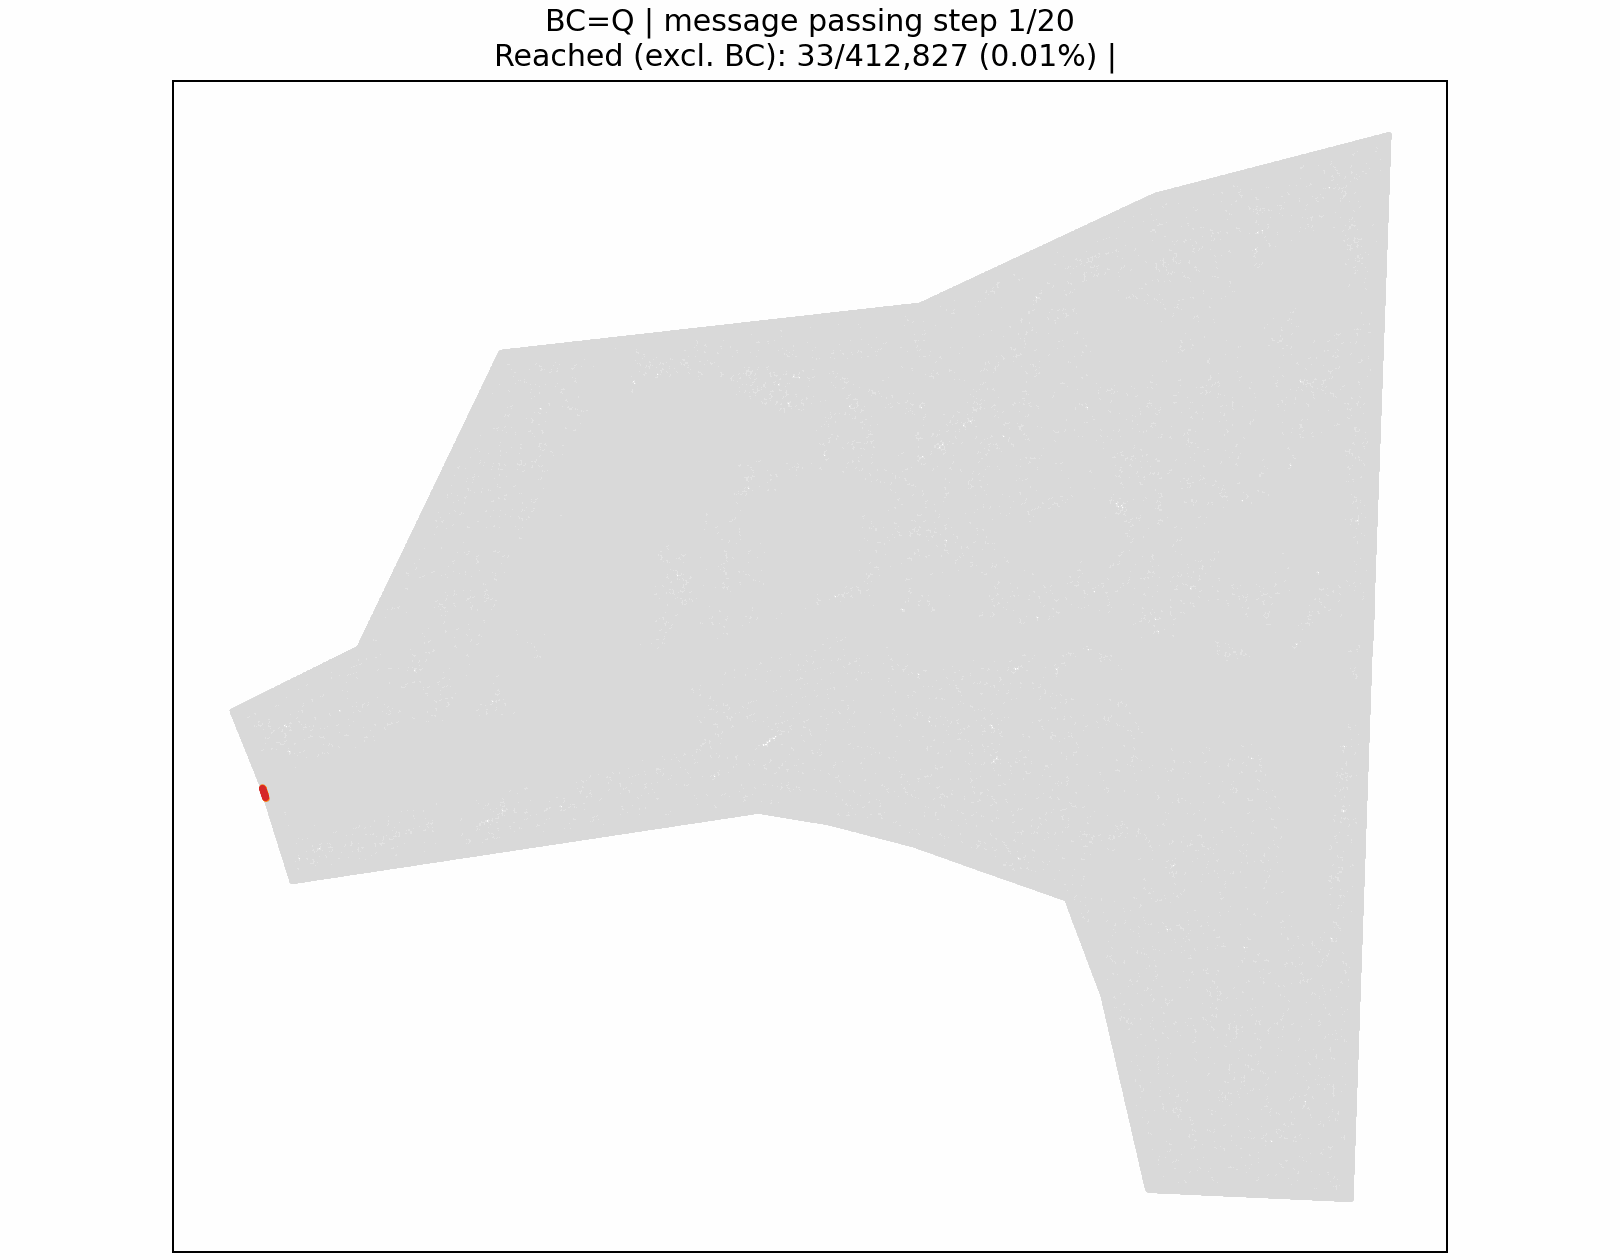

In [4]:
mesh_file = Path(MESH_FILE).expanduser().resolve()
cli_file = None if CLI_FILE is None else Path(CLI_FILE).expanduser().resolve()

if cli_file is None:
    res = TelemacFile(str(mesh_file))
else:
    res = TelemacFile(str(mesh_file), bnd_file=str(cli_file))

tri = res.tri
x = np.asarray(tri.x)
y = np.asarray(tri.y)
triangles = np.asarray(tri.triangles)
num_nodes = x.shape[0]

try:
    node_type = extract_node_type(tri, res.get_bnd_info())
except Exception as exc:
    raise RuntimeError(
        'Could not read boundary-condition info. Check CLI_FILE and mesh file.'
    ) from exc

bc_mask, q_mask, h_mask, wall_mask = get_bc_mask(node_type, BC_TYPE)
bc_count = int(bc_mask.sum())
if bc_count == 0:
    raise RuntimeError(
        f'No BC source nodes found for BC_TYPE={BC_TYPE}. '
        f'Counts: q={int(q_mask.sum())}, h={int(h_mask.sum())}, wall={int(wall_mask.sum())}'
    )

adjacency = build_adjacency(triangles, num_nodes)
dist = multi_source_hop_distance(adjacency, bc_mask)

non_bc_count = int((~bc_mask).sum())
max_hops = max(1, int(MAX_HOPS))

OUTPUT_DIR = Path(OUTPUT_DIR)
frames_dir = OUTPUT_DIR / 'frames'
frames_dir.mkdir(parents=True, exist_ok=True)

tri_plot = mtri.Triangulation(x, y, triangles)
frame_paths = []
csv_rows = []

for step in range(1, max_hops + 1):
    reached = (dist >= 0) & (dist <= step)
    reached_no_bc = reached & (~bc_mask)
    frontier = dist == step
    frontier_no_bc = frontier & (~bc_mask)
    unreached_or_far = (~reached) & (~bc_mask)

    reached_including_bc = int(reached.sum())
    reached_excluding_bc = int(reached_no_bc.sum())
    newly_reached_including_bc = int(frontier.sum())
    newly_reached_excluding_bc = int(frontier_no_bc.sum())
    frac_excluding_bc = reached_excluding_bc / non_bc_count if non_bc_count > 0 else float('nan')

    csv_rows.append({
        'step': step,
        'reached_including_bc': reached_including_bc,
        'reached_excluding_bc': reached_excluding_bc,
        'newly_reached_including_bc': newly_reached_including_bc,
        'newly_reached_excluding_bc': newly_reached_excluding_bc,
        'fraction_excluding_bc': frac_excluding_bc,
    })

    fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)
    if DRAW_MESH_LINES:
        ax.triplot(tri_plot, color='#e4e4e4', linewidth=0.25, zorder=1)

    if np.any(unreached_or_far):
        ax.scatter(x[unreached_or_far], y[unreached_or_far], s=NODE_SIZE, c='#d8d8d8', alpha=0.8, linewidths=0, zorder=2)
    if np.any(reached_no_bc):
        ax.scatter(x[reached_no_bc], y[reached_no_bc], s=NODE_SIZE, c='#1f77b4', alpha=0.9, linewidths=0, zorder=3)
    if np.any(frontier_no_bc):
        ax.scatter(x[frontier_no_bc], y[frontier_no_bc], s=max(4.0, NODE_SIZE * 2.2), c='#ff7f0e', alpha=1.0, linewidths=0, zorder=4)
    if np.any(bc_mask):
        ax.scatter(x[bc_mask], y[bc_mask], s=max(5.0, NODE_SIZE * 2.4), c='#d62728', alpha=1.0, linewidths=0, zorder=5)

    ax.set_aspect('equal', adjustable='box')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(
        f'BC={BC_TYPE.upper()} | message passing step {step}/{max_hops}\n'
        f'Reached (excl. BC): {reached_excluding_bc:,}/{non_bc_count:,} ({100.0 * frac_excluding_bc:.2f}%) | ',
        fontsize=12,
    )

    frame_path = frames_dir / f'bc_reach_step_{step:02d}.png'
    fig.savefig(frame_path, dpi=DPI)
    plt.close(fig)
    frame_paths.append(frame_path)

counts_csv = OUTPUT_DIR / 'bc_reach_counts.csv'
save_counts_csv(csv_rows, counts_csv)

gif_path = OUTPUT_DIR / 'bc_reach_1_to_k_full.gif'
gif_ok = False
if not SKIP_GIF:
    gif_ok = save_gif_with_pillow(frame_paths, gif_path, fps=FPS)

print('=== Generation complete ===')
print(f'Mesh: {mesh_file}')
print(f'BC type: {BC_TYPE} | Sources: {bc_count:,} nodes')
print(f'Nodes total: {num_nodes:,} | Non-BC: {non_bc_count:,}')
print(f'Frames dir: {frames_dir}')
print(f'Counts CSV: {counts_csv}')
if SKIP_GIF:
    print('GIF: skipped (SKIP_GIF=True)')
elif gif_ok:
    print(f'GIF: {gif_path}')
else:
    print('GIF: not created (install Pillow).')

if gif_ok:
    try:
        from IPython.display import Image, display
        display(Image(filename=str(gif_path)))
    except Exception:
        pass